# ASP3231 Laboratory 4: Calibrated Catalogues

In this week's laboratory we going to use archival data to estimate V-band magnitudes of bright stars, create a catalogue of celestial objects using Monash C14 data and use that catalogue to produce a histogram of astronomical magnitudes.

## Prelab Questions

You are expected to read the lab notebook prior to the lab, and the Prelab Questions are designed to prompt you to consider what you have read. This will hopefully prepare you for the lab session and ultimately save time.

#### Question 1: Why do the magnitudes of stars depend on the filter they are measured in?

#### Question 2: If a star has a colour of B-V=0 why does it typically have roughly U-B=0 and V-R=0 too (for Vega-basd magnitudes)?

#### Question 3: Open AladinLite (https://aladin.u-strasbg.fr/AladinLite/), find NGC 4755 (Jewel Box) and use the SIMBAD catalogue to determine the name and V-band magnitude of a star. (Note SIMBAD magnitudes are archival and of varying quality, sometimes using CCD photometry but on occassion using photographic plate photometry).

#### Question 4: Plot a parabola in using matplotlib. There's plenty of resources online, but make significant changes if you make use of online resources and comment your code accordingly.

#### Question 5: Produce a histogram using matplotlib for a list that you've written yourself. Have at least ten numbers in your list. 


<font color=green>

**Question 1:** Stars do not emit light equally across all wavelengths. We can often assume they are blackbodies, but this isn't always the case. A very bright blue star will still appear dimmer in a red filter. 

**Question 2:** The star Vega is, by definition, given a magnitude of 0 in the U, B, V, R, and I filters. If a star were to coincidentally have B-V=0, it would essentially have a similar colour index to that of Vega, and we could then predict that U-B and V-R would also be approximately zero due to our definition of the magnitudes.

**Question 3:** NGC 4755 407 is a star in NGC 4755 with a V-band magnitude of 12.81.

**Question 4 and 5:** Refer to next code cell.

</font>

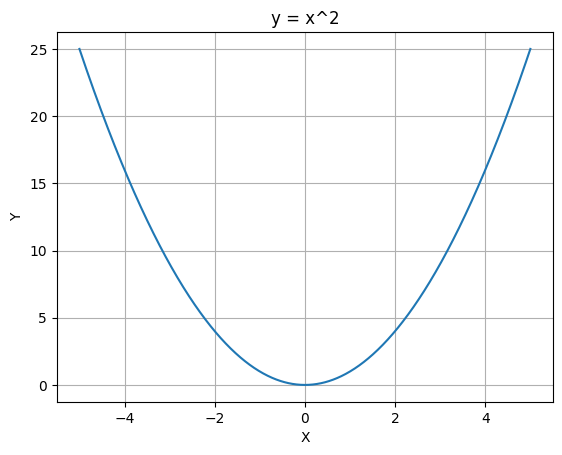

[2 7 5 5 3 6 4 2 5 1 6 5 4 1 4]


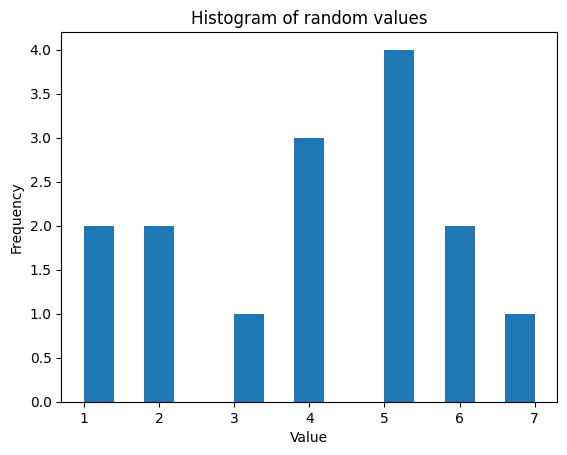

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create an array of x-coordinates
x = np.linspace(-5, 5, 1000)
# Map to y-coordinates with f(x)
y = x**2

# Plotting logic
plt.figure(0)
plt.plot(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("y = x^2")
plt.grid()
plt.show()

# Generate a random 12-element array of integers to display
rng = np.random.default_rng()
histogram_list = rng.integers(low=1, high=8, size=(15))
print(histogram_list)
# Plotting logic
plt.figure(1)
plt.hist(histogram_list, bins=len(histogram_list))
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of random values")
plt.show()

**Task 1.** As always we import various libraries. A new one this week is astroquery - what does it do?

In [2]:
# Import various libraries 

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii

from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc                               

from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


<font color=green>**Note:** The astroquery library is a unified API used to access data from online astronomical catalogues like SIMBAD

For our photometric calibration we will use a star in our science field with Gaia photometry. To convert from the Gaia band photometry in the UBVRI band photometry we must model the relationship between UBVRI photometry and Gaia photometry using stars with well measured magnitudes. This is done using Graham (1982) UBVRI standard stars that have Gaia photometry.

A csv file of the Graham (1982) standards with Gaia photometry is already available. We can load this into our notebook into the form of a table. 

**Task 2.** Read the Graham - Gaia data into a table, and add to the code below to print an example row and an example column.

In [3]:

Graham = ascii.read("GrahamGaia.csv", format='csv', fast_reader=False)

print(Graham) # Print out all the data

print(Graham[23])  # Just the 24th row of data

print(Graham.columns[3]) # Just the 4th column - right ascension seconds

    Star     RAh RAm ...         G                 GRP        
------------ --- --- ... ------------------ ------------------
[CS62] E1 41   1  24 ...   5.93287467956543  5.254235744476318
[CS62] E1 35   1  22 ...  8.931272506713867  8.081226348876953
[CS62] E1 20   1  23 ...  9.661012649536133  9.133469581604004
[CS62] E1 44   1  24 ...              -99.9              -99.9
[CS62] E1 49   1  24 ... 11.499369621276855 11.046634674072266
 [CS62] E1 a   1  25 ... 12.540872573852539 12.065360069274902
 [CS62] E1 h   1  24 ... 13.685699462890625 13.169958114624023
 [CS62] E1 i   1  24 ... 13.522989273071289 12.887176513671875
 [CS62] E1 p   1  24 ...   14.5486421585083 13.951996803283691
 [CS62] E2 2   4   3 ... 7.6066083908081055 7.4743475914001465
         ... ... ... ...                ...                ...
 [CS62] E8 u  20   7 ...  15.77283763885498 15.287020683288574
[CS62] E9 27  22  43 ...  9.108248710632324  8.364110946655273
[CS62] E9 38  22  48 ...  9.034331321716309   8.2070789

<font color=green>**Note:** We have imported all the data from the local csv file of the Graham 1982 standards. We can access specific rows and columns of this data that include the information on each object (location, magnitudes, etc.).

**Task 3.** Lets now plot V minus G as a function of Gaia G_BP minus G, and fit that data. Write the equation that gives V band magnitude as a function of Gaia photometry. This equation allows us to estimate V-band magnitudes from Gaia magnitudes for main sequence stars, while correcting for the difference between V-band and Gaia G. 


[0.4438681  0.26560882 0.0039465 ]


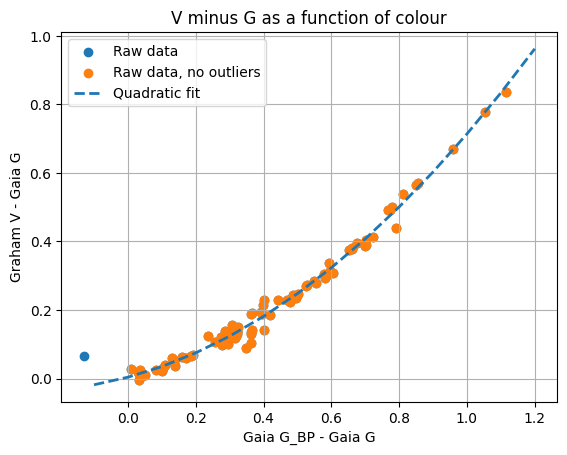

In [4]:
# Plot the difference between V and G as a function of Gaia G_BP and G.

# Here we will initialise the empty arrays.
px=[]        # px will be filled with G_BP minus G for each star in the Graham catalogue
py=[]        # py will be filled with V minus G for each star in the catalogue
for Star in Graham:
    # Check if we have valid Graham and Gaia magnitudes and colours.
    # Remember we sometimes use -99 to denote a missing value. 

    # If the star has magnitudes in each band between 0 and 30.
    if Star['Vmag']>0.0 and Star['Vmag']<30.0 and \
    Star['GBP']>0.0 and Star['GBP']<30.0 and \
    Star['G']>0.0 and Star['G']<30.0 and \
    (Star['Vmag']-Star['G'])**2<2.25 :         # Only match if V and G are similar
        
        # Append to master lists
        px.append(Star['GBP']-Star['G'])      # G_BP minus G
        py.append(Star['Vmag']-Star['G'])          # V minus G

plt.title('V minus G as a function of colour')       # Title
plt.ylabel('Graham V - Gaia G')                      # y-label
plt.xlabel('Gaia G_BP - Gaia G')                     # x-label
plt.scatter(px, py, marker='o', label="Raw data");                     # Plot px on x-axis, py on y-axis, using dots as marker points 

# Fit to this data 

# This is the same process as before
px=[]      
py=[]        
for Star in Graham:
    # Check if we have valid Graham and Gaia magnitudes and colours.
    # Remember we sometimes use -99 to denote a missing value. 
    # !!! We have included another condition to remove outliers here, that G_BP - G is positive. I have explained below.
    if Star['Vmag']>0.0 and Star['Vmag']<30.0 and \
    Star['GBP']>0.0 and Star['GBP']<30.0 and \
    Star['G']>0.0 and Star['G']<30.0 and \
    Star['GBP']-Star['G']>0.0 and \
    (Star['Vmag']-Star['G'])**2<2.25 :             # Only match if V and G are similar
        px.append(Star['GBP']-Star['G'])           # G_BP minus G
        py.append(Star['Vmag']-Star['G'])          # V minus G

# Numpy's polyfit function is a polynomial fitter. It's primary role is to determine the coefficients of y = ax^2 + bx + c. It should, thus, return a tuple of our three coefficients. The 2 indicates the polynomial degree, in this case quadratic.
Vpoly=np.polyfit(px, py, 2)                           
print(Vpoly)                                          

plx=np.arange(-0.1, 1.3, 0.1).tolist() # arange is creating an array of values from -0.1 to 1.3, using spacing of 0.1 units between each element.

# Here we will cast each x-value in plx to it's y-value using our polyfit function
ply=[]
for x in plx:
    # All we are doing here is applying the function f(x), using our coefficients in the polyfit list. For example a = polyfit[0] and so on.
    ply.append(Vpoly[2]+Vpoly[1]*x+Vpoly[0]*x*x) # ply = f(x)

plt.title('V minus G as a function of colour')       # Title
plt.ylabel('Graham V - Gaia G')                      # y-label
plt.xlabel('Gaia G_BP - Gaia G')                     # x-label
plt.scatter(px, py, marker='o', label="Raw data, no outliers");                     # This is our raw data of G_BP - G vs V - G.
plt.plot(plx, ply, linestyle='dashed', linewidth=2, label="Quadratic fit"); # This is our polynomial fit
plt.grid()
plt.legend()


<font color=green>**Note:** This graph has essentially plotted V - G magnitudes for various stars in our Graham catalogue with respect to their colours determined using Gaia photometry (G_BP - G). Our first loop recursively determined all the raw data, determine both values for all the stars. We only included stars with G, G_BP, and V all between 0 and 30, and having G_BP and V fairly similar. We plotted this first as blue dots.

The next part was fitting the data. One important difference we made here was omitting outliers. To do this, we redid all the magnitude and colour calculations for all the stars and put them in new arrays, but this time including the condition that G_BP - G is positive, which should be the case as the star's blue light should generally have less flux than all the star's wavelengths (remember, higher magnitude = dimmer/less flux).

Including this difference, we call the polyfit function from Numpy to get our quadratic coefficients, and plot both our new (outlier-less) raw data and also the new polynomial fit.

SIGNIFICANT POINTS:
- Without specifying colours, matplotlib will automatically change the colour of the same data formats. Because we overlaid the new clean data over the old data with outliers, it drew it on top of the old data with a new orange marker. We can see that the majority of our stars are drawn in orange, but one of them on the left is drawn in blue, indicating it remained from the first data plot. It is clearly an outlier as it lies below zero and would have been cutoff by our new condition. It also was not included in the polyfit calculation.
- I have included a plot legend to show this more clearly.

#### Rewrite V-G as a function of GBP-G to get V from Gaia photomety 


**Task 4.** Adapt the code above to plot and fit Graham R minus Gaia G_RP as a function of Gaia G minus Gaia G_RP. This allows us to estimate R-band magnitudes from Gaia magnitudes for main sequence stars, while accounting for the difference between the R-band and G_RP band.

**Hint:** Don't reuse Vpoly and instead create Rpoly.

[0.48173421 0.24264534 0.03572866]


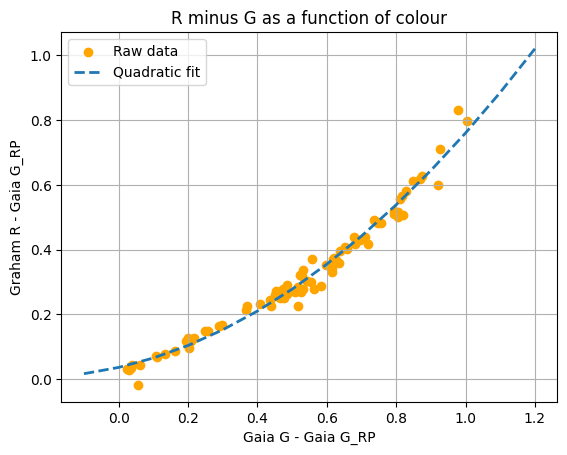

In [5]:
# Add R-magnitude column by performing basic operation on the other data
Graham['Rmag'] = Graham['Vmag'] - Graham['V-R']

# We will fill our arrays of the raw data, same as before but with the new magnitudes
px=[]      
py=[]        
for Star in Graham:
    # Check if we have valid Graham and Gaia magnitudes and colours.
    # This part includes the condition to remove outliers

    if Star['Rmag']>0.0 and Star['Rmag']<30.0 and \
    Star['GBP']>0.0 and Star['GBP']<30.0 and \
    Star['G']>0.0 and Star['G']<30.0 and \
    Star['GBP']-Star['G']>0.0 and \
    (Star['Rmag']-Star['G'])**2<2.25 :             # Only match if R and G are similar
        px.append(Star['G']-Star['GRP'])           # G minus G_RP
        py.append(Star['Rmag']-Star['GRP'])          # R - G_RP

# Call the polynomial fitter again to get coeffs
Rpoly=np.polyfit(px, py, 2)                           
print(Rpoly)                                          

plx=np.arange(-0.1, 1.3, 0.1).tolist() # arange is creating an array of values from -0.1 to 1.3, using spacing of 0.1 units between each element.

# Here we will cast each x-value in plx to it's y-value using our polyfit function
ply=[]
for x in plx:
    # All we are doing here is applying the function f(x), using our coefficients in the polyfit list. For example a = polyfit[0] and so on.
    ply.append(Rpoly[2]+Rpoly[1]*x+Rpoly[0]*x*x) # ply = f(x)

plt.title('R minus G as a function of colour')       # Title
plt.ylabel('Graham R - Gaia G_RP')                      # y-label
plt.xlabel('Gaia G - Gaia G_RP')                     # x-label
plt.scatter(px, py, marker='o', label="Raw data", color='orange');                     # This is our raw data of G_BP - G vs V - G.
plt.plot(plx, ply, linestyle='dashed', linewidth=2, label="Quadratic fit"); # This is our polynomial fit
plt.grid()
plt.legend()

<font color=green>**Note:** Here we have followed much the same process. The only significant difference is that we have had to make the column of R magnitudes by performing a basic operation on our data, which was R = V - (V - R) since we have columns for both V and V-R. Now we have stored the coefficients in Rpoly instead of Vpoly.

**Task 5.** A bright star in Jewel Box (HD 111990) is located at RA=193.49911961463 DEC=-60.33542302933, and has G_BP=6.85, G=6.69 and G_RP=6.43. Run the following Gaia query to confirm the photometry.

In [6]:
# Set Gaia magnitudes to junk values 
gmag=[-99.0, -99.0, -99.0]

# Get coordinates in decimal degrees
rad=193.49912
decd=-60.33542

coord = SkyCoord(ra=rad, dec=decd, unit=(u.degree, u.degree), frame='icrs')
# Match radius in degrees
radius = u.Quantity(0.001, u.deg)

# Run query and return results
j = Gaia.cone_search_async(coordinate=coord, radius=radius)
r = j.get_results()
# If there is a result then print the first match
if len(r)>0:
    gmag[0] = r[0]['phot_bp_mean_mag']
    gmag[1] = r[0]['phot_g_mean_mag']
    gmag[2] = r[0]['phot_rp_mean_mag']
    print(gmag)

INFO: Query finished. [astroquery.utils.tap.core]
[np.float32(6.830305), np.float32(6.7034516), np.float32(6.430051)]


<font color=green>**Note:** The query has found a star at our target location and we can see that its magnitudes match to at least two decimal places. So the photometry is confirmed.

**Task 6.** Determine the V and R band magnitudes for this star. To do this use your previous results for V - G as a function of G_BP - G, and R - G_RP as a function of G - G_RP. (If the Gaia query did not run then use the values stated in the notebook.)

In [7]:

# Here we have made rearrangements to our fit equations. Recall we have a fit of V - G = f(G_BP - G) and R - G_RP = f(G - G_RP)
# For V, we can see that V = G + f(G_BP - G) where G_BP and G are gmag[0] and gmag[1] respectively.
# For R, it is the same thing now but R = G_RP + f(R - G_RP) where G_RP is gmag[2].
target_Vmag = Vpoly[0]*(gmag[0]-gmag[1])**2 + Vpoly[1]*(gmag[0]-gmag[1]) + Vpoly[2] + gmag[1]
target_Rmag = Rpoly[0]*(gmag[1]-gmag[2])**2 + Rpoly[1]*(gmag[1]-gmag[2]) + Rpoly[2] + gmag[2]

print(target_Vmag)
print(target_Rmag)

6.748234174512555
6.568127595288654


<font color=green>**Note:** Our magnitudes align with the Gaia query.

**Task 7.** We are now going to generate a catalogue of objects for the Jewel Box Cluster. As the stars in our Jewel Box image are reasonably well seperated, we will use the segmentation (rather than model fit approach). Run the following code and comment on what each line is doing and what the plot shows (add axis labels and a caption).

Today's image, new-image.fits, is a copy of an image taken with the C14 telescope with a world coordinate system added using astrometry.net. 

In [8]:
scim=CCDData.read("new-image.fits", unit="adu")   # Read the image

w = scim.wcs                                      # Read the World Coordinate System
print(w)

med=np.median(scim.data)                          # Median pixel value
scim.data=scim.data-med                           # Use the median for the sky subtraction

# Here we will extract the mean, median, and standard deviation of the image data file
mean, median, std = astropy.stats.sigma_clipped_stats(scim.data, sigma=3.0, maxiters=5)    
print('Image stats (mean, median and standard deviation):', mean,median,std)

# detect_sources is a Photutils function that detects image objects using standard deviation of flux
# It returns a data file but has scaled all the flux values, a pixel is zero if no object, and is a positive number of there is an object there. The objects are numbered in order of detection, 1, 2, 3, and so on.
segimage=detect_sources(scim.data, 2.00*std, 9, connectivity=4, mask=None)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP'
CUNIT : 'deg' 'deg'
CRVAL : 193.362772634 -60.3703641988
CRPIX : 1934.45053101 1462.70141602
CD1_1 CD1_2  : -7.56232600033e-05 -4.95501395149e-06
CD2_1 CD2_2  : 5.03421624158e-06 -7.55965823534e-05
NAXIS : 3358  2536


Image stats (mean, median and standard deviation): 0.14082895 -0.19646645 29.830463


<font color=green>**Note:** The new data saved in 'segimage' is purely displaying the locations of objects in the image. It should be black where there is not an object, and bright where there is an object.

**Task 8.** Comment on what is being plotted here. How does segimage (segmentation image) compare to the ds9 image of Jewel Box?

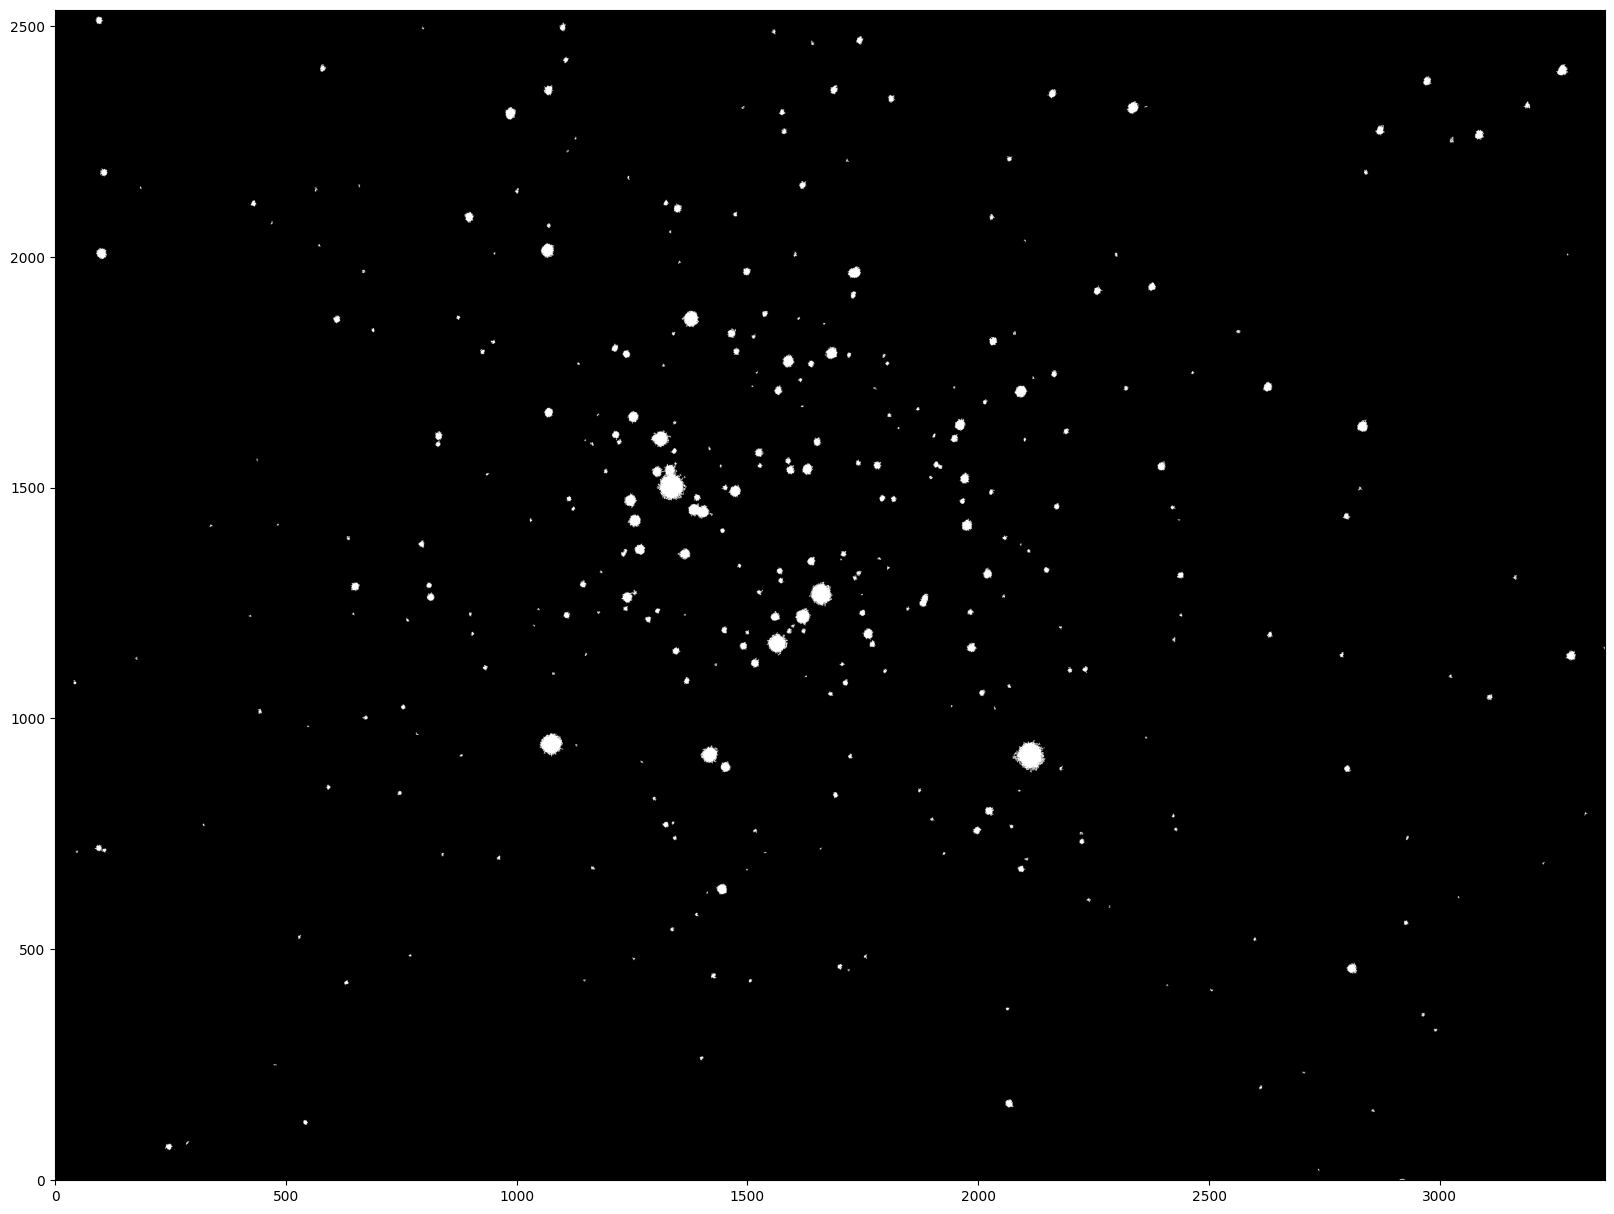

In [9]:
plt.figure(figsize=(20,20))

# This is plotting the segimage data of our star catalogue. It should be black where no object is detected and it should be a positive increasing number where there is an object, depending on the object's unique detection ID.
plt.imshow(segimage.data, cmap='gray', vmin=0, vmax=1, origin='lower')


<font color=green>**Note:** I also opened the original image of Jewel Box in ds9 to see what it looks like. We can see a typical FITS image where there is a noisy background and the stars all have their respective fluxes. ds9 also correctly shows the world coordinate system that has been added. This is different to the segimage which has absolutely no noise and is a pure display of where there is or is not an object, based on our detection parameters using the standard deviation.

**Task 9.** The following code writes the segmentation image to an output FITS file. Compare the segmentation image with the original image using ds9, and discuss what you see (i.e. how the images differ, and the pixel values for the segmentation map).

In [10]:
outfile="segimage.fits"                # Set the output file name
hdu=fits.PrimaryHDU(segimage)          # Define a FITS header for this data
# Convert WCS to header format
wcsheader = w.to_header(relax=True)
hdu.header.extend(wcsheader)
hdu.writeto(outfile, overwrite=True)   # Write the output and overwrite existing files if needed. 


<font color=green>**Note:** As expected, the pixel values are completely different. Since the segimage is only designed to show us where there are and are not objects, each unique object has its own numbered ID. From bottom-to-top it goes from 1 onwards. The background is completely black. For example, one of the main objects in the middle is 'Object 204' as determined by all the pixels in the object having a pixel value of 204, unrelated to the flux of the object which is stored in the original fits file. The only similarity between our images is that the objects are in the same location.

**Task 10.** Let's now convert the segmentation map into a catalogue of object positions using the following code.


In [11]:
# Collate all the different entries in segimage into a table of data with x-y values and world coordinate values obtained from the header data
source_table=SourceCatalog(scim.data, segimage, error=None, mask=None, background=None, wcs=w)
print('Source table length:\n', len(source_table)) # Number of objects in our catalogue
print('\n\n')

# We can see here that each object has a 'centroid' data which is a vector of its coordinates
print('First entry centroid x and y values :') 
print(source_table[0].centroid[0], source_table[0].centroid[1])
print('\n\n')

# We can fetch the wcs data of each object using .sky_centroid_icrs
print('First source sky icrs coordinates :') # 
print(source_table[0].sky_centroid_icrs)
print(source_table[0].sky_centroid_icrs.ra, source_table[0].sky_centroid_icrs.dec)


Source table length:
 354



First entry centroid x and y values :
2918.3464606253883 0.4681426312742773



First source sky icrs coordinates :
<SkyCoord (ICRS): (ra, dec) in deg
    (193.22804378, -60.2548552)>
193d13m40.95760413s -60d15m17.47873071s


<font color=green>**Note:** Now we have a catalogue of all our objects.

**Task 11.** The following code switches the source table list of centroids into a list of positions that can then be used for photometry. Adapt code from previous weeks to now run 20 pixel radius aperture photometry on this list of object positions.


In [12]:
# Positions is a list of every object's centroid
positions=[]
for obj in source_table:                                   # Step through list of sources
    positions.append((obj.centroid[0], obj.centroid[1]))   # Positions for source photometry are x-y

# Call CircularAperture to get all the apertures that we will use. This doesn't do much, only recasts our data into the right object type for the library to use.
apertures = CircularAperture(positions, r=20)

# Now we will add up the flux
phot_table = aperture_photometry(scim.data, apertures)
print(phot_table[0:10]) # Print out some sample results to see what has been done

 id      xcenter            ycenter           aperture_sum   
--- ------------------ ------------------ -------------------
  1 2918.3464606253883 0.4681426312742773  1925.6740112356997
  2 2737.1828269068637  21.63361082196824  -913.0913156859153
  3 246.40736849666035  71.99322008991862   37084.65858977432
  4  286.2811294559992   80.1064472419734  2988.5334301289768
  5  542.0951523040715 124.23264900150268    8783.04703974727
  6 2855.0462008288428  149.8879751632971  2934.7669716832906
  7  2066.210534730938 165.28452012018164   69082.52796440182
  8 2611.7056894213397 200.16249017094128  2839.1032612406757
  9  2704.768945607123 232.16425000985623 -422.10317591210537
 10  476.2260860495117 248.99035350809393   912.4721138061548


<font color=green>**Note:** Using some of the code from last week's lab, we can create the 20 pixel apertures over all the objects, and count up all the flux values in our original images using these apertures. Looking at some of the results, we can see the total flux of our objects.

**Task 12.** What flux (counts) have you measured for the bright star HD 111990 in Jewel Box that is located at RA=193.49911961463 DEC=-60.33542302933? Use https://aladin.u-strasbg.fr/AladinLite/ and ds9 to identify this star identify this star in your images and to get some of this star's key details. (Remember SIMBAD magnitudes are archival and of varying quality, sometimes using CCD photometry but on occassion using very old photographic plate photometry.)

ds9 usually displays coordinates in h\:m\:s and d\:m\:s format, but this can be changed to decimal degrees using the WCS menu.

In [13]:
# Clue - here's ways to query a range of positions in a photometry table
# Clue for projects - if you have a list of photometry tables, you may 
# need to do a for loop over phot_tables[0] rather than phot_table

# We will loop through all the apertures and their fluxes
for idx, obj in enumerate(phot_table):

    # Define our target coordinates to tell the library where to look.
    c1 = SkyCoord('193.499deg', '-60.335deg', frame='icrs')
    # Fetch the wcs coordinates of the star in our catalogue
    c2 = SkyCoord(source_table[idx].sky_centroid_icrs.ra, source_table[idx].sky_centroid_icrs.dec, frame='icrs')
    # Calculate the separation between them
    sep = c1.separation(c2)
    # If they are separated by less than 10 arcseconds (then it is most likely a match)
    if sep.value<10.0/3600.0:
        print('Separation less than 10 arcseconds')
        print(c1, c2)
        print(obj)

Separation less than 10 arcseconds
<SkyCoord (ICRS): (ra, dec) in deg
    (193.499, -60.335)> <SkyCoord (ICRS): (ra, dec) in deg
    (193.49923379, -60.33536655)>
 id      xcenter            ycenter         aperture_sum  
--- ------------------ ----------------- -----------------
 82 1074.1073553380193 943.1149925761813 4502823.382675131


<font color=green>**Note:** The star in our catalogue at these coordinates is listed as star 82 as determined in ds9. The code also confirms this. Using the online SIMBAD catalogue we can fetch some more details about the star (HD 111990). It is listed as a blue supergiant with the following magnitudes: B=6.95, V=6.78, R=7.68, J=6.123, H=6.05, K=6.015.

**Task 13.** Determine the V-band magnitude of the fainter star near x=1444 y=629 using the flux of this star in ADU (from phot_table) and the estimated V-band magnitude and flux in ADU of HD 111990. This is simply using:
\begin{equation}
m_1 - m_2 = -2.5{\rm log_{10}} \left(\frac{f_1}{f_2} \right)
\end{equation}

Take care to use np.log10 and not np.log (which is natural log).

<font color=green>**Note:** This is star 35 in our catalogue.

In [14]:
# Now we will use x and y image coordinates rather than using the world coordinate system used in the previous task. The previous task is an arguably better way of doing it, since it isn't localised by what our specific image size is. But this is a faster and easier way for us to do it since we know what we're looking for.

# These are the pixel coordinates (x and y) of our target star
xstar = 1444
ystar = 629

for idx, obj in enumerate(phot_table):
    # Check if the target star is within a 10 pixel radius of our target coordinates
    if (obj['xcenter']-xstar)**2+(obj['ycenter']-ystar)**2<10.0**2:
        print(obj)
        
        # FLUX CALCULATION using Vmag of HD 111990 of 6.78
        # Aperture sums stored in phot_table. Use 81 for the 82nd star, which is HD 111990 (0-based indexing)
        target_Vmag = 6.78 - 2.5 * np.log10(phot_table[idx]['aperture_sum']/phot_table[81]['aperture_sum'])
        
        print(f"\nV-band magnitude of the fainter star: {target_Vmag:.3f}.")



 id      xcenter           ycenter         aperture_sum  
--- ----------------- ----------------- -----------------
 35 1444.131331676691 629.3197205118938 234588.2362206658

V-band magnitude of the fainter star: 9.988.


<font color=green>**Note:** We can see that our code successfully identified that we are trying to look for star 35. To find the V-band magnitude we just use the given equation with our flux values from phot_table and the SIMBAD V-band magnitude for HD 111990. It comes out to be 9.988.

**Task 14.** Is there a way you could check your V-band magnitude above is in the right ballpark? Can you compare to other stars or use an online database? This could be a test done manually with a web interface or an automated query. 

<font color=green>I found the star online using the SIMBAD catalogue, matching my WCS coordinates with those in ds9 over my object. The name is CPD-59 4550. The object type refers to the star being a 'Beta Cephei' star that lies on the main sequence. The listed V-band magnitude is 10.29 which is relatively close to my result about 0.2 difference. This is acceptable for quite a few reasons:
- The SIMBAD data is 20 years old, so they technology used may have been quite different.
- The results I got would vary based on my chosen pixel radius and how the images were processed. It is quite unlikely that I had the same conditions that the original researchers did.

Overall, my result is acceptable and representative of the star's true V-magnitude.


**Task 15.** Produce a list (array) of V-band magnitudes for all the stars in Jewel Box.

In [15]:
maglist=[] # Initialise the empty list

# Loop through every element of our aperture photometry objects
for idx, obj in enumerate(phot_table):
    # Ensure they have a positive flux to avoid NaN errors
    if phot_table[idx]['aperture_sum'] > 0:
        # This is the exact same formula used above
        object_Vmag = 6.78 - 2.5 * np.log10(phot_table[idx]['aperture_sum']/phot_table[81]['aperture_sum'])
    else:
        # Handle NaN objects by catching them and setting it to NaN, printing a message
        object_Vmag = float("nan")
        print(f"Index {idx} is invalid -> negative flux.")
    
    # Save to the master list
    maglist.append(object_Vmag)

print(f"\nCheck to see the 35th star matches our previous result: {maglist[34]:.3f}.\n\nAll values:")
print(maglist)

Index 1 is invalid -> negative flux.
Index 8 is invalid -> negative flux.
Index 18 is invalid -> negative flux.

Check to see the 35th star matches our previous result: 9.988.

All values:
[np.float64(15.20225535858047), nan, np.float64(11.990726568799204), np.float64(14.725066985987372), np.float64(13.55459925984735), np.float64(14.744778224633727), np.float64(11.315291727925924), np.float64(14.780759310241002), nan, np.float64(16.013163279682683), np.float64(13.888163797853373), np.float64(14.111720417580354), np.float64(13.80904606257554), np.float64(13.909232367658252), np.float64(14.231721370055315), np.float64(14.423725135281575), np.float64(13.34104159691815), np.float64(13.769970133962365), nan, np.float64(13.07551846633259), np.float64(10.548360543376209), np.float64(13.347793274923234), np.float64(12.864573522855952), np.float64(14.09069708175631), np.float64(13.99641803888516), np.float64(15.799572292404385), np.float64(13.840144644770014), np.float64(14.272909691166205), np

<font color=green>**Note:** Here I have just ran the same formula for every star in the list, saving it to a master list called maglist which lists all V-magnitudes of all the stars in our catalogue. We can see that three of the stars failed since they have negative fluxes.

**Task 16.** Produce a histogram of the magnitudes of the stars in Jewel Box using matplotlib. Ideally set the range so the bin width is 0.5 mag per bin. 

Hint: https://stackoverflow.com/questions/33203645/how-to-plot-a-histogram-using-matplotlib-in-python-with-a-list-of-data

Hint: Ideally you should only plot plausible magnitudes (i.e. not -90 and not +90).


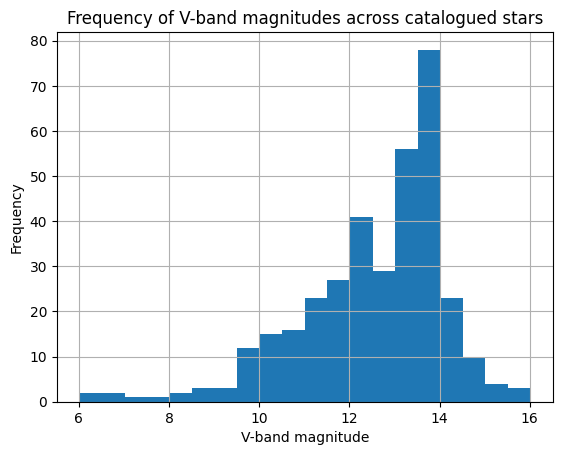

In [16]:
# Plotting logic
plt.figure()
# Number of bins is the number of entries of an arange from min to max, spaced 0.5 mag per bin
plt.hist(maglist, bins=len(np.arange(min(maglist), max(maglist), 0.5)))
plt.xlabel("V-band magnitude")
plt.ylabel("Frequency")
plt.title("Frequency of V-band magnitudes across catalogued stars")
plt.grid()
plt.show()

<font color=green>**Note:** We can see that the majority of our objects have magnitudes between 13 and 14. The histogram looks like a normal distribution centered about 13.5 and is slightly skewed to the right.

# Don't forget your conclusions

<font color=green>

## Conclusion
The primary goal accomplished in this task was taking a FITS image of the Jewel Box cluster and creating our own catalogue of stars in the image, and determining their magnitudes. We established a calibration framework from Graham (1982) UBVRI standard stars as well as the Gaia photometry and determined quadratic fit polynomials to convert between Gaia bands into standard magnitudes. We did this for the blue supergiant HD 111990, getting a V-band magnitude of 6.748. We then used this as a reference for the rest of the stars in our catalogue. One specific example, CPD-59 4550, we got a magnitude of 9.988 compared to the SIMBAD value of 10.29, a small discrepancy that can be explained due to many differences including aperture radius and instruments used. We obtained V-band magnitudes for 351 different objects - down from 354 in the catalogue because 3 of them were so dim in the original image that the background dominated the aperture and produced a negative result (either dim star or cloud cover). Our magnitudes follow a normal trend centred around 13.5 mag. The right skewing is typical of an open cluster where there are more mid-to-faint main sequence stars. What was demonstrated here was a standard practice and a good foundation for observational astronomy, whereby a calibrated source catalogue was extracted from raw aperture photometry.

</font>